# Hands-on Solution: Scientific QnA System with OpenAI embeddings and chromaDB and SciFacts dataset

This notebook provides a step-by-step solution for verifying scientific claims using the SciFact dataset, OpenAI LLMs, and the ChromaDB Vector Store for context retrieval.

#### Import Required Libraries and Set Up OpenAI Client

Import all necessary libraries for data handling, visualization, and OpenAI API access. Set up the OpenAI client for making API calls.

In [2]:
# Install required packages if not already installed
# !pip install openai pandas matplotlib scikit-learn

import os
import openai
import pandas as pd
import json
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Set display options for pandas
display_cols = 120
pd.set_option('display.max_colwidth', None)

In [3]:
# Set up OpenAI client
client = openai.Client()

# Set the model for all API calls
OPENAI_MODEL = "gpt-4o"

#### Load and Explore SciFact Claims Dataset

Load the SciFact claims dataset into a pandas DataFrame, inspect its structure, and view sample entries.

In [4]:
# Set the data path to the SciFact dataset
# Update this path if your data is stored elsewhere
data_path = r'D:\Makesh\Working\AI\RPS\Day07\hands-on exercise'

In [5]:
# Function to read a JSONL file into a pandas DataFrame
def read_jsonl_to_dataframe(file_path):
    data_list = []
    with open(file_path, 'r') as file:
        for line in file:
            data = json.loads(line)
            data_list.append(data)
    return pd.DataFrame(data_list)

In [6]:
import json

In [7]:
# Load the claims dataset
claim_df = read_jsonl_to_dataframe(f'{data_path}/claims_train.jsonl')

# Inspect the DataFrame
print('Shape:', claim_df.shape)
print('Columns:', claim_df.columns.tolist())

claim_df.sample(5)

Shape: (809, 4)
Columns: ['id', 'claim', 'evidence', 'cited_doc_ids']


,id,claim,evidence,cited_doc_ids
516,899,Oxidative DNA damage inhibits STING signalling.,{},"[13106686, 5572127]"
371,645,Intake of folic acid (FA) and vitamin B6 (VB6) increases levels of homocysteine.,"{'12810152': [{'sentences': [0], 'label': 'CONTRADICT'}]}",[12810152]
698,1215,The effect of Lipopolysaccharides on kidney barrier function is dependent on inflammation levels.,{},[16355392]
696,1212,The deregulated and prolonged activation of monocytes has deleterious effects in chronic infectious conditions.,{},"[6493422, 44724517]"
408,696,Lipopolysaccharides have an inflammation independent effect on kidney barrier function.,{},[16355392]


#### Assess Ground Truth Labels

Randomly sample 50 claims from the DataFrame. For each claim, examine the `evidence` field and assign a ground-truth label:
- **True**: All evidence is SUPPORT.
- **False**: Any evidence is CONTRADICT.
- **NEE**: No evidence or unclear support/contradict.

This list will be used as the reference for evaluating model predictions.

In [8]:
# Sample 50 claims for evaluation
sampled = claim_df.sample(n=50, random_state=42).reset_index(drop=True)

In [9]:
# Function to extract ground-truth label from evidence
def get_groundtruth_label(evidence):
    if not evidence or len(evidence) == 0 or evidence == {}:
        return 'NEE'
    found_contradict = False
    found_support    = False
    
    for doc_evidence in evidence.values():
        for item in doc_evidence:
            if item['label'] == 'CONTRADICT':
                found_contradict = True
            elif item['label'] == 'SUPPORT':
                found_support = True
                
    if found_contradict:
        return 'False'
    elif found_support:
        return 'True'
    else:
        return 'NEE'

In [10]:
# Apply the function to the sampled claims
groundtruth_labels = [get_groundtruth_label(ev) for ev in sampled['evidence']]

print(groundtruth_labels)
# Example output: ['True', 'False', 'NEE', ...]

['NEE', 'False', 'NEE', 'NEE', 'NEE', 'True', 'False', 'NEE', 'False', 'True', 'False', 'NEE', 'True', 'True', 'True', 'True', 'True', 'True', 'True', 'False', 'False', 'False', 'False', 'NEE', 'NEE', 'True', 'False', 'NEE', 'NEE', 'True', 'False', 'NEE', 'False', 'NEE', 'True', 'True', 'NEE', 'NEE', 'True', 'True', 'NEE', 'NEE', 'True', 'True', 'NEE', 'NEE', 'True', 'NEE', 'NEE', 'True']


#### Evaluate Claims Using OpenAI LLM

For each sampled claim, build a prompt with clear instructions and a few example shots. Query the OpenAI LLM (e.g., gpt-4o) and collect the model's responses for all sampled claims.

In [11]:
# Build prompt with instruction and few-shot examples
def build_prompt(claim):
    return [
        {"role": "system", "content": "I will ask you to assess a scientific claim. Output only the text 'True' if the claim is true, 'False' if the claim is false, or 'NEE' if there's not enough evidence."},
        {"role": "user", "content": f"""
Claim:
0-dimensional biomaterials show inductive properties.
Assessment:
False

Claim:
1/2000 in UK have abnormal PrP positivity.
Assessment:
True

Claim:
Aspirin inhibits the production of PGE2.
Assessment:
False

End of examples.

Assess the following claim:

Claim:
{claim}
Assessment:
"""}
    ]

In [12]:
# Function to query OpenAI LLM for each claim
def assess_claims_llm(claims):
    responses = []
    for claim in claims:
        response = client.chat.completions.create(
            model      = OPENAI_MODEL,
            messages   = build_prompt(claim),
            max_tokens = 5,
            temperature= 0.001
        )
        # Clean up the response
        result = response.choices[0].message.content.strip('., \n ')
        responses.append(result)
    return responses

In [13]:
# Evaluate the sampled claims
sampled_claims = sampled['claim'].tolist()
llm_responses  = assess_claims_llm(sampled_claims)

print(llm_responses)
# Example output: ['True', 'False', 'NEE', ...]

['NEE', 'NEE', 'True', 'NEE', 'NEE', 'NEE', 'False', 'True', 'False', 'True', 'True', 'NEE', 'NEE', 'True', 'NEE', 'True', 'True', 'NEE', 'NEE', 'NEE', 'True', 'NEE', 'NEE', 'True', 'True', 'True', 'NEE', 'True', 'True', 'True', 'False', 'True', 'True', 'NEE', 'True', 'True', 'NEE', 'False', 'True', 'True', 'False', 'NEE', 'True', 'True', 'True', 'True', 'NEE', 'NEE', 'True', 'True']


#### Compare Ground Truth with LLM Inferred Output

Compare the ground-truth labels with the LLM-inferred labels for the sampled claims. Visualize the results using a confusion matrix and analyze the model's strengths, weaknesses, and any systematic biases.

In [14]:
# Compare ground-truth and LLM-inferred labels
labels = ['True', 'False', 'NEE']

Confusion Matrix (Ground Truth vs LLM):
[[13  0  6]
 [ 3  3  5]
 [10  2  8]]


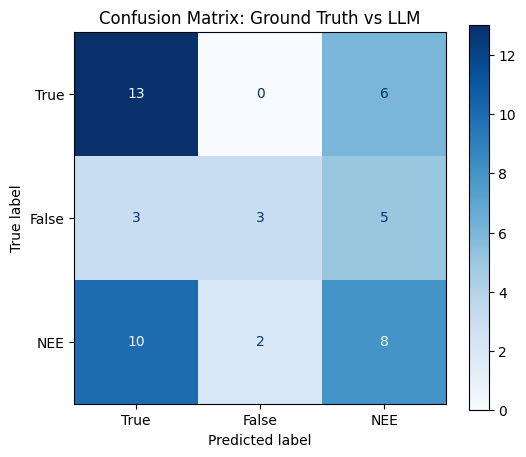

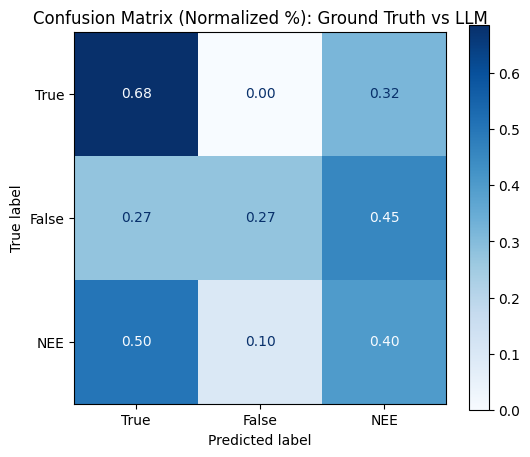

In [15]:
# Compute confusion matrix
cm = confusion_matrix(groundtruth_labels, llm_responses, labels=labels)

# Display confusion matrix
print('Confusion Matrix (Ground Truth vs LLM):')
print(cm)

# Visualize confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap="Blues", values_format="d", ax=ax)
plt.title("Confusion Matrix: Ground Truth vs LLM")
plt.show()

# Normalized confusion matrix (row-wise %)
cm_normalized = confusion_matrix(groundtruth_labels, llm_responses, labels=labels, normalize='true')
fig, ax = plt.subplots(figsize=(6, 5))
disp_norm = ConfusionMatrixDisplay(confusion_matrix=cm_normalized, display_labels=labels)
disp_norm.plot(cmap="Blues", values_format=".2f", ax=ax)
plt.title("Confusion Matrix (Normalized %): Ground Truth vs LLM")
plt.show()

#### Analysis and Discussion of LLM Performance

Examine the confusion matrix results to understand the LLM's strengths and weaknesses in scientific claim verification:
- **Diagonal values** indicate correct predictions; off-diagonal values show misclassifications.
- **True/False distinction**: High values on the 'True' and 'False' diagonals suggest the LLM can distinguish supported and contradicted claims well. Off-diagonal errors may indicate confusion between these classes.
- **NEE (Not Enough Evidence)**: If the LLM frequently predicts 'NEE' for claims with clear evidence, it may be overly cautious. Conversely, if it rarely predicts 'NEE', it may be overconfident.
- **Systematic biases**: Look for patterns, such as the LLM favoring 'True' or 'False' regardless of evidence, or consistently missing 'NEE' cases.
- **Potential causes of errors**:
    - Ambiguous or complex claims.
    - Insufficient or unclear prompt examples.
    - LLM limitations in scientific reasoning or fact retrieval.

**Discussion Points:**
- Where does the LLM perform best? (e.g., clear-cut True/False claims)
- Where does it struggle? (e.g., borderline or NEE cases)
- Are there any systematic misclassifications?
- How might prompt engineering or context retrieval improve results?
- What are the implications for real-world scientific fact-checking?

#### Task: Adding Context for Claim Assessment

**Objective:**  
- Enhance the model's ability to assess claims accurately by providing relevant context from external data sources.

**Why Add Context?**
- LLMs may not have up-to-date or domain-specific knowledge for every scientific claim.
- Providing relevant paper titles and abstracts helps the model ground its reasoning in real evidence, reducing hallucinations and uncertainty.

**Example 1: True Claim**
- *Claim*: "Vitamin D supplementation reduces the risk of bone fractures in elderly adults."
- *Context Retrieved*:
    - Title: "Vitamin D and Bone Health in the Elderly"
    - Abstract: "A meta-analysis of randomized controlled trials shows that vitamin D supplementation significantly reduces fracture risk among elderly populations."
- *LLM Assessment with Context*: Likely to output **True**, citing the supporting evidence.

**Example 2: False Claim**
- *Claim*: "Aspirin increases the risk of developing Alzheimer's disease."
- *Context Retrieved*:
    - Title: "Aspirin Use and Cognitive Decline"
    - Abstract: "Multiple studies find no association between aspirin use and increased risk of Alzheimer's; some suggest a protective effect."
- *LLM Assessment with Context*: Likely to output **False**, referencing the lack of supporting evidence and possible contradiction.

**Example 3: Not Enough Evidence (NEE)**
- *Claim*: "Drinking green tea cures COVID-19."
- *Context Retrieved*:
    - Title: "Green Tea and Viral Infections"
    - Abstract: "While green tea has some antiviral properties, there is no clinical evidence supporting its use as a cure for COVID-19."
- *LLM Assessment with Context*: Likely to output **NEE**, noting the absence of direct evidence.

**Expected Benefits:**
- Reduces the number of 'NEE' responses due to lack of knowledge.
- Improves accuracy, especially for 'False' claims, by enabling the model to cross-check claims against real data.
- Makes the model's reasoning more transparent and trustworthy for scientific fact-checking.

#### Task: Loading Corpus into OpenAI Vector Store

- Load the SciFact corpus into a DataFrame for processing.
- For each document, combine the `title` and `abstract` fields to create a single text chunk for embedding.
- Upload the corpus to the OpenAI vector store in batches of 50 documents at a time.
- After uploading, use a sample claim as a query to retrieve the top-3 most relevant documents from the vector store.
- Analyze the retrieved documents to assess their relevance to the query claim.

In [16]:
# Load the SciFact corpus into a DataFrame
corpus_df = pd.read_json(f'{data_path}/corpus.jsonl', lines=True)

# Inspect the corpus DataFrame
print('Shape:', corpus_df.shape)
print('Columns:', corpus_df.columns.tolist())
corpus_df.sample(3)

Shape: (5183, 4)
Columns: ['doc_id', 'title', 'abstract', 'structured']


,doc_id,title,abstract,structured
4539,37029185,Quality of life in patients with advanced heart failure.,"[Although evaluation of the treatment of congestive heart failure is usually based on objective clinical outcomes, patient self-assessment is increasingly recognized as an important component of evaluation., A study was designed to measure the quality of life of 134 patients with symptoms of advanced heart failure who were being evaluated for possible heart transplantation., The patients' quality of life was assessed using a mix of subjective and objective measures, including functional status, physical symptoms, emotional state, and psychosocial adaptation., There was no significant relationship between patients' cardiac ejection fraction and any quality-of-life measures; however, the results of a 6-minute walking test, New York Heart Association classification, and self-reported functional status were all significantly correlated with psychosocial adjustment., Self-reported functional status, depression, and hostility accounted for 43% of the variance in total psychosocial adjustment to illness., These findings support the inclusion of quality of life as an outcome measure in any evaluation of treatment efficacy and suggest that interventions to improve the quality of life of patients with advanced heart failure need to be targeted at reducing depression and hostility and increasing daily activity levels.]",False
4250,31890716,Association of plasma resistin with glomerular filtration rate and albuminuria in hypertensive adults.,"[Resistin, a recently discovered proinflammatory cytokine, has been variably associated with insulin resistance, inflammation, and renal dysfunction., We investigated the association of plasma resistin with estimated glomerular filtration rate and albuminuria in 1575 hypertensive adults without known coronary heart disease or stroke (857 blacks and 718 non-Hispanic whites)., Resistin was measured by a solid phase sandwich immunoassay, estimated glomerular filtration rate was estimated from serum creatinine, and albuminuria was expressed as urine albumin:creatinine ratio., After adjustment for coronary heart disease risk factors (age, sex, body mass index, smoking history, systolic blood pressure, diabetes, and total and high-density lipoprotein cholesterol) and use of renin-angiotensin blockers and statins, higher plasma resistin levels were associated with lower estimated glomerular filtration rate in both ethnic groups (each P<0.0001); the association remained significant after further adjustment for a marker of insulin resistance (homeostasis model assessment for insulin resistance) and a marker of inflammation (plasma C-reactive protein) and was seen in subjects with and without diabetes (each P<0.0001) in both ethnic groups., Higher plasma resistin levels were associated with a higher urine albumin:creatinine ratio in black subjects with diabetes (P<0.0001) and non-Hispanic white subjects with diabetes (P=0.032), independent of coronary heart disease risk factors, hypertension medication use, and statin use; the association remained significant after additional adjustment for homeostasis model assessment for insulin resistance and C-reactive protein., In adults with hypertension, higher circulating resistin levels were associated with a lower estimated glomerular filtration rate and with increased urine albumin:creatinine ratio in the presence of concomitant diabetes., This association was independent of coronary heart disease risk factors and markers of insulin resistance and inflammation.]",False
1373,7583104,"IDEAL in meshes for prolapse, urinary incontinence, and hernia repair.","[PURPOSE Mesh surgeries are counted among the most frequently applied surgical procedures., Despite global spread of mesh applying surgeries, there is no current systematic analysis of incidence and possible prevention of adverse events after mesh implantation. , MATERIALS AND METHODS Based on the recommendation

In [17]:
# Combine title and abstract for each document to create a single text chunk for embedding
# Some abstracts are lists; join them into a string first
def combine_title_abstract(row):
    title = row['title'] if isinstance(row['title'], str) else ''
    abstract = row['abstract']
    if isinstance(abstract, list):
        abstract = ' '.join([str(x) for x in abstract])
    elif not isinstance(abstract, str):
        abstract = str(abstract)
    return title + '\n' + abstract

corpus_df['text'] = corpus_df.apply(combine_title_abstract, axis=1)

# Show a sample combined text
corpus_df[['doc_id', 'text']].sample(3)

,doc_id,text
1864,11016788,"sasCIF: an extension of core Crystallographic Information File for SAS\nData acquisition packages developed at different small angle scattering facilities use different formats both for raw and processed data storage. To facilitate the data exchange between laboratories, a consensus in the small angle scattering community has been reached on an ASCII format for one-dimensional data which includes a self-describing header containing relevant information about the sample and instrumental conditions followed by raw or reduced data in a tabular form. This format called sasCIF was implemented as an extension of core CIF (Crystallographic Information File) dictionary."
1825,10675756,"Related IgA1 and IgG producing cells in blood and diseased mucosa in ulcerative colitis.\nBACKGROUND Ulcerative colitis (UC) is a chronic inflammatory bowel disease in which the colonic mucosa is infiltrated with plasma cells producing IgG autoantibodies. It is not known whether this represents a local mucosal response which has switched to IgG or a peripheral response which may have been initiated by peripheral antigen which homed to the colonic mucosa. The clonal distribution of IgG secreting cells and isotype switched variants in UC is not known. AIMS To investigate the clonal distribution of mucosal IgG in UC and to search for related IgG and IgA secreting cells in normal and diseased mucosa and blood in UC. To investigate characteristics which may discriminate between the mucosal and peripheral repertoire in the normal mucosa and in UC. \n PATIENTS Blood and normal and diseased mucosa from two patients with UC were studied. \n METHODS Immunoglobulin gene analysis and clone specific polymerase chain reaction were used to study the clonal distribution and characteristics of IgG and related IgA in the mucosa and blood of patients with UC. \n RESULTS The IgG response in the mucosa of UC patients included widespread clones of cells that were present in both the diseased mucosa and blood but that were scarce in normal mucosa. Clonally related IgA class switch variants, all IgA1, were detected but also only in the diseased mucosa and blood. This suggests that these clones home preferentially to the diseased mucosa. We showed that J(H)1 usage was characteristic of the peripheral repertoire, and that examples of J(H)1 usage were observed in mucosal IgG in UC. \n CONCLUSIONS Overall, these data are consistent with a model of UC in which a peripheral response is expressed and expanded in the colonic mucosa."
1927,11527199,"MHC Haplotype Matching for Unrelated Hematopoietic Cell Transplantation\nBackground Current criteria for the selection of unrelated donors for hematopoietic cell transplantation (HCT) include matching for the alleles of each human leukocyte antigen (HLA) locus within the major histocompatibility complex (MHC). Graft-versus-host disease (GVHD), however, remains a significant and potentially life-threatening complication even after HLA-identical unrelated HCT. The MHC harbors more than 400 genes, but the total number of transplantation antigens is unknown. Genes that influence transplantation outcome could be identified by using linkage disequilibrium (LD)-mapping approaches, if the extended MHC haplotypes of the unrelated donor and recipient could be defined."


In [18]:
# --- Use OpenAI Embeddings for Corpus Text (with ChromaDB) ---
# This cell computes OpenAI embeddings for each corpus text and stores them in ChromaDB.

# Install required packages if not already installed
# !pip install openai chromadb

In [19]:
import chromadb
from tqdm import tqdm

In [20]:
# Initialize ChromaDB client and collection
chroma_client = chromadb.Client()
collection = chroma_client.create_collection(name="scifact_qna_bks")

In [21]:
# Function to get OpenAI embeddings for a list of texts
EMBED_MODEL = "text-embedding-3-small"  # Or "text-embedding-ada-002"

def get_openai_embeddings(texts, model=EMBED_MODEL, batch_size=100):
    embeddings = []
    
    for i in tqdm(range(0, len(texts), batch_size)):
        batch = texts[i:i+batch_size]
        response     = client.embeddings.create(input=batch, model=model)
        batch_embeds = [item.embedding for item in response.data]
        
        embeddings.extend(batch_embeds)
        
    return embeddings

In [22]:
%time

# Prepare data for ChromaDB with OpenAI embeddings
texts     = corpus_df['text'].tolist()

# Use doc_id as both the id and as a metadata field for easy lookup
ids       = corpus_df['doc_id'].astype(str).tolist()
metadatas = [{"doc_id": doc_id} for doc_id in ids]

# Compute OpenAI embeddings
embeddings = get_openai_embeddings(texts)

# Add to ChromaDB
collection.add(
    embeddings=embeddings,
    documents=texts,
    metadatas=metadatas,
    ids=ids
)

print(f"Added {len(texts)} documents to ChromaDB collection with OpenAI embeddings.")

CPU times: total: 0 ns
Wall time: 3.58 μs


100%|██████████| 52/52 [01:18<00:00,  1.52s/it]


Added 5183 documents to ChromaDB collection with OpenAI embeddings.


#### --- Querying and Visualizing ChromaDB Vector Store ---

In [23]:
# Query ChromaDB for relevant documents given a claim
query_claim = "Vitamin D supplementation reduces the risk of bone fractures in elderly adults."

# Get embedding for the query using OpenAI
query_embedding = get_openai_embeddings([query_claim])[0]

# Search ChromaDB for top-3 most similar documents (remove 'ids' from include)
results = collection.query(
    query_embeddings=[query_embedding],
    n_results=3,
    include=["documents", "metadatas", "distances"]
)

# Display the results
for i, (doc, meta, dist) in enumerate(zip(results['documents'][0], results['metadatas'][0], results['distances'][0])):
    doc_id = meta.get('doc_id', 'N/A')
    print(f"Rank {i+1} | doc_id: {doc_id} | Distance: {dist:.4f}")
    print(f"Title: {corpus_df.loc[corpus_df['doc_id']==int(doc_id), 'title'].values[0] if doc_id != 'N/A' else 'N/A'}")
    print(f"Text: {doc[:300]}...\n")

100%|██████████| 1/1 [00:00<00:00,  2.12it/s]

Rank 1 | doc_id: 9555784 | Distance: 0.7569
Title: Vitamin d deficiency in postmenopausal women - biological correlates.
Text: Vitamin d deficiency in postmenopausal women - biological correlates.
INTRODUCTION Low vitamin D (VD) is associated with secondary hyperparathyroidism and both contribute to deleterious consequences (reduced bone mineral density (BMD), risk of fractures and falls).   
 OBJECTIVE To study the VD stat...

Rank 2 | doc_id: 4462079 | Distance: 0.8065
Title: Estimation of optimal serum concentrations of 25-hydroxyvitamin D for multiple health outcomes.
Text: Estimation of optimal serum concentrations of 25-hydroxyvitamin D for multiple health outcomes.
Recent evidence suggests that vitamin D intakes above current recommendations may be associated with better health outcomes. However, optimal serum concentrations of 25-hydroxyvitamin D [25(OH)D] have not...

Rank 3 | doc_id: 11246427 | Distance: 0.8905
Title: Effect of alendronate on risk of fracture in women with lo

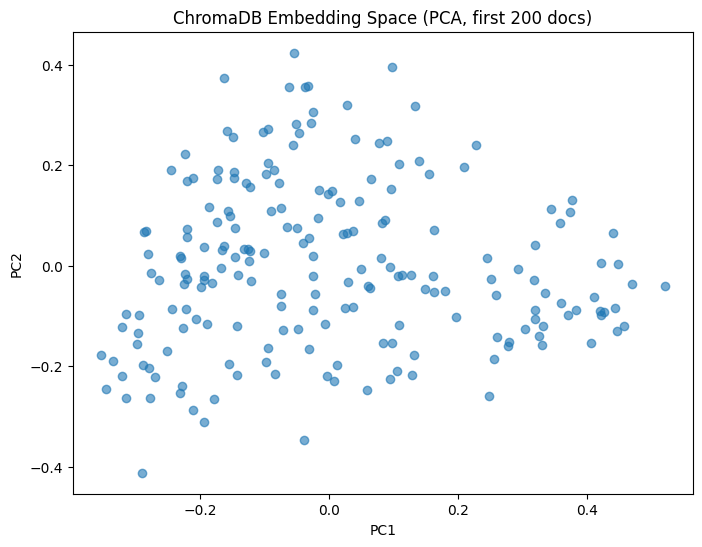

In [24]:
# Plotting the embedding space (optional, for small datasets)
from sklearn.decomposition import PCA
import numpy as np

# Reduce dimensionality for visualization (e.g., first 200 docs)
embeddings_np = np.array(embeddings[:200])
pca = PCA(n_components=2)
embeddings_2d = pca.fit_transform(embeddings_np)

plt.figure(figsize=(8,6))
plt.scatter(embeddings_2d[:,0], embeddings_2d[:,1], alpha=0.6)
plt.title("ChromaDB Embedding Space (PCA, first 200 docs)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

#### Exploratory Data Analysis (EDA) with ChromaDB embeddings

**1. Dimensionality Reduction & Visualization**
- *Objective*: Project high-dimensional embeddings into 2D/3D space using PCA, t-SNE, or UMAP to visually inspect the structure of the embedding space. Identify clusters, outliers, and patterns. Color points by metadata (e.g., document type, topic, or label) to reveal relationships and groupings.

**2. Clustering**
- *Objective*: Apply clustering algorithms (KMeans, DBSCAN, Agglomerative) to group similar documents based on their embeddings. Analyze the resulting clusters to discover natural groupings, dominant themes, or potential anomalies in the dataset.

**3. Similarity Distribution**
- *Objective*: Compute and plot histograms of pairwise cosine distances between embeddings to understand the spread and density of the embedding space. Analyze nearest neighbor distances to detect dense clusters or sparse regions, which may indicate outliers or unique topics.

**4. Outlier Detection**
- *Objective*: Identify embeddings that are far from all others, which may correspond to data errors, rare topics, or unique documents. Use distance-based or clustering-based methods to flag potential outliers for further inspection.

**5. Query Analysis**
- *Objective*: For a set of sample queries, analyze which documents are most frequently retrieved as top matches. Visualize the distribution of distances for top-k results to assess retrieval quality and embedding space structure. Identify documents that are highly central or frequently retrieved, as well as those rarely matched.

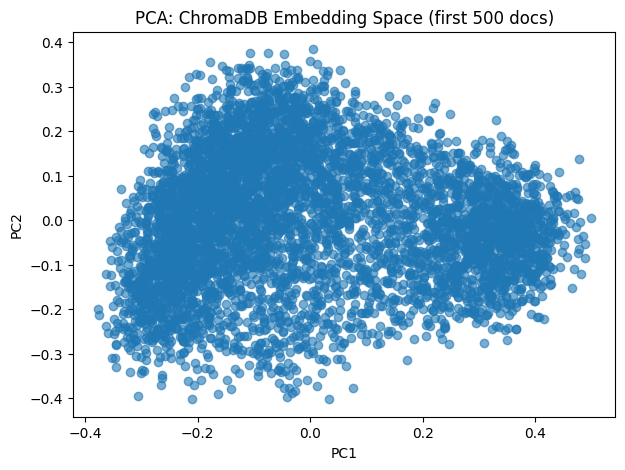

In [25]:
# --- EDA Topic 1: Dimensionality Reduction & Visualization ---
# Objective: Project high-dimensional embeddings into 2D/3D space using PCA, t-SNE, or UMAP to visually inspect the structure of the embedding space.
# Identify clusters, outliers, and patterns. Color points by metadata (e.g., document type, topic, or label) to reveal relationships and groupings.

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import numpy as np
import matplotlib.pyplot as plt

# Select a subset for visualization 
# N = 500
# embeddings_np = np.array(embeddings[:N])
embeddings_np = np.array(embeddings)

# Option 1: PCA (fast, linear)
pca = PCA(n_components=2)
embeddings_pca = pca.fit_transform(embeddings_np)

plt.figure(figsize=(7,5))
plt.scatter(embeddings_pca[:,0], embeddings_pca[:,1], alpha=0.6)
plt.title("PCA: ChromaDB Embedding Space (first 500 docs)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

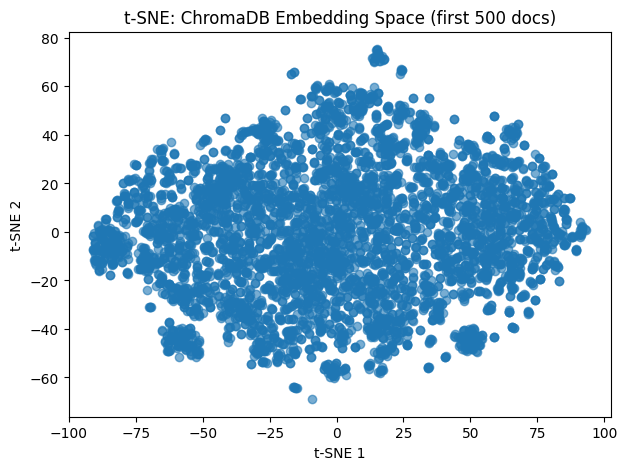

In [26]:
# Option 2: t-SNE (nonlinear, preserves local structure)
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
embeddings_tsne = tsne.fit_transform(embeddings_np)

plt.figure(figsize=(7,5))
plt.scatter(embeddings_tsne[:,0], embeddings_tsne[:,1], alpha=0.6)
plt.title("t-SNE: ChromaDB Embedding Space (first 500 docs)")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.show()


d:\Makesh\Working\AI\Python_Envs\gen_ai\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


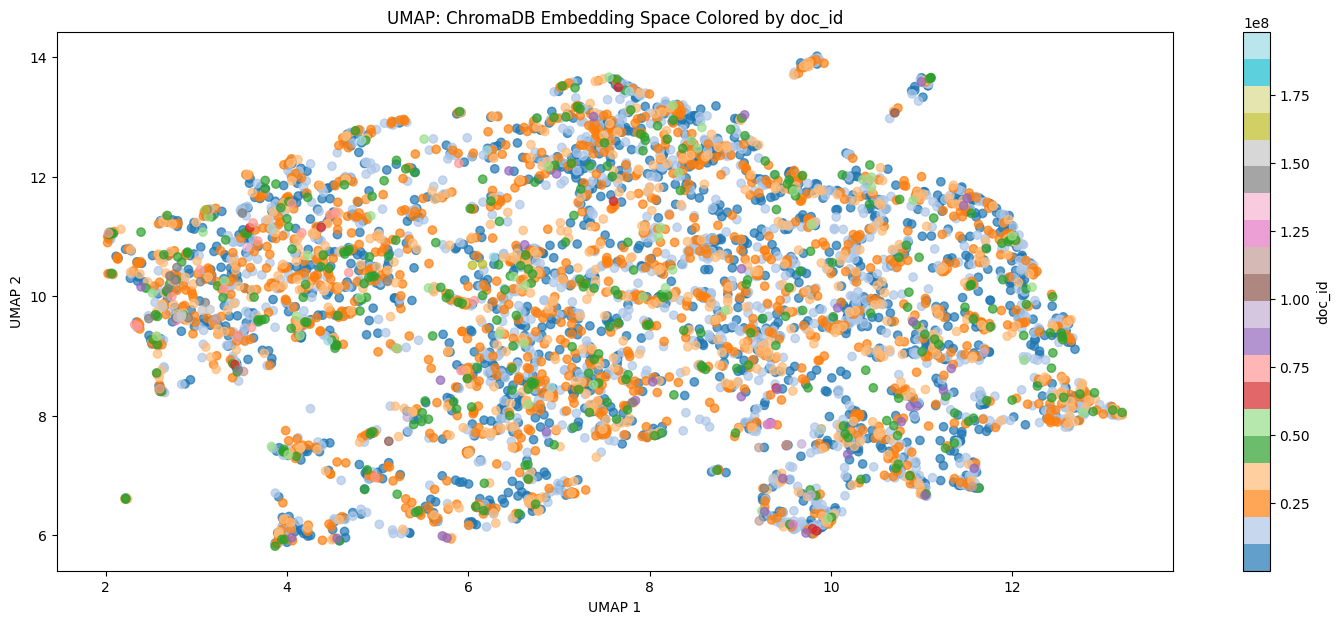

In [27]:
# Option 3: UMAP (nonlinear, preserves global and local structure)
# !pip install umap-learn  # Uncomment if UMAP is not installed
import umap

umap_reducer = umap.UMAP(n_components=2, random_state=42)
embeddings_umap = umap_reducer.fit_transform(embeddings_np)

# Color by doc_id (metadata)
doc_ids = np.array(ids[:len(embeddings_umap)]) if 'ids' in locals() else np.arange(len(embeddings_umap))
plt.figure(figsize=(18,7))
scatter = plt.scatter(embeddings_umap[:,0], embeddings_umap[:,1], c=doc_ids.astype(int), cmap='tab20', alpha=0.7)
plt.title("UMAP: ChromaDB Embedding Space Colored by doc_id")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.colorbar(scatter, label='doc_id')
plt.show()

**2. Clustering of ChromaDB Embeddings**

- In this section, we apply clustering algorithms (KMeans and DBSCAN) to the document embeddings.
- The goal is to group similar documents, visualize clusters, and analyze their properties.
- We will also inspect the size and characteristics of each cluster.

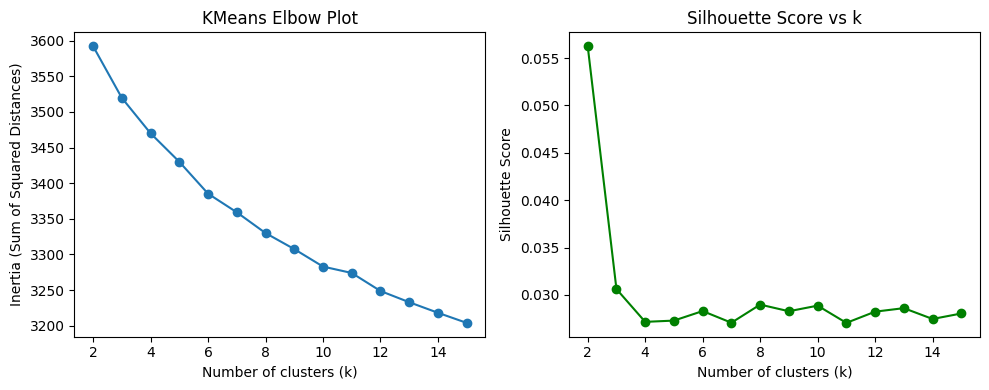

Optimal k by silhouette score: 2
Silhouette Score for k=2: 0.056


In [28]:
# --- EDA Topic 2: Clustering (KMeans Elbow & Silhouette) ---
# Perform KMeans clustering on all/raw embeddings, plot the elbow plot, show silhouette score, and interpret results.

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import numpy as np
import matplotlib.pyplot as plt

# Use all raw embeddings
X = np.array(embeddings)

# Elbow plot: compute inertia for a range of k
inertias = []
sil_scores = []
k_range = range(2, 16)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X)
    inertias.append(kmeans.inertia_)
    sil = silhouette_score(X, labels)
    sil_scores.append(sil)

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(list(k_range), inertias, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia (Sum of Squared Distances)')
plt.title('KMeans Elbow Plot')

plt.subplot(1,2,2)
plt.plot(list(k_range), sil_scores, marker='o', color='green')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score vs k')
plt.tight_layout()
plt.show()

# Choose optimal k (e.g., by elbow or max silhouette)
optimal_k = sil_scores.index(max(sil_scores)) + 2  # +2 because k_range starts at 2
print(f'Optimal k by silhouette score: {optimal_k}')

# Final KMeans with optimal k
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42)
final_labels = kmeans_final.fit_predict(X)
final_sil_score = silhouette_score(X, final_labels)
print(f'Silhouette Score for k={optimal_k}: {final_sil_score:.3f}')

**Interpretation of KMeans Clustering Results**

- **Elbow Plot**: The elbow plot shows how the within-cluster sum of squared distances (inertia) decreases as the number of clusters increases. The 'elbow' point suggests a good trade-off between model complexity and explained variance. Choose the k at the elbow or where inertia reduction slows down.

- **Silhouette Score**: This metric measures how similar each point is to its own cluster compared to other clusters. A higher silhouette score (closer to 1) indicates well-separated, dense clusters. The plot helps select the k with the best cluster separation.

- **Optimal k**: The optimal number of clusters is chosen based on the maximum silhouette score or the elbow point. This value balances compactness and separation of clusters.

- **Cluster Quality**:
    - If the silhouette score is high (>0.5), clusters are well-defined.
    - If the score is low (<0.2), clusters may overlap or the data may not be naturally clusterable.
    - If the elbow is not clear, the data may be uniformly distributed or high-dimensional noise.

- **Next Steps**:
    - Inspect cluster contents to understand their themes or topics.
    - Visualize clusters (if needed) using dimensionality reduction.
    - Use cluster assignments for downstream analysis, such as outlier detection or topic modeling.

In [30]:
from sklearn.cluster import DBSCAN

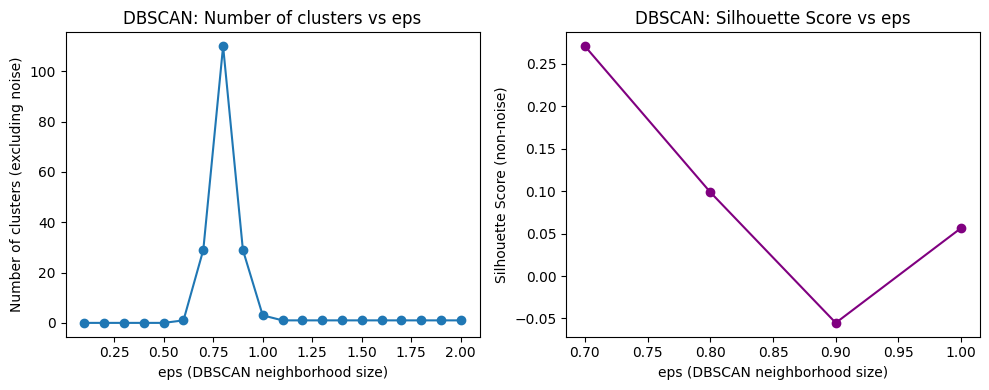

Best eps by silhouette score: 0.70 (score=0.271)


In [31]:
# DBSCAN (density-based, can find outliers)
# Clustering is performed on the raw embeddings, not on any reduced or projected space.
from sklearn.metrics import silhouette_score
import numpy as np
import matplotlib.pyplot as plt

# Try a range of eps values for DBSCAN and compute silhouette scores (elbow plot is not meaningful for DBSCAN)
X = np.array(embeddings)
eps_values = np.linspace(0.1, 2.0, 20)
sil_scores = []
n_clusters_list = []
for eps in eps_values:
    dbscan = DBSCAN(eps=eps, min_samples=5)
    labels = dbscan.fit_predict(X)
    # DBSCAN labels -1 for noise; silhouette_score requires at least 2 clusters and no all-noise
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_clusters_list.append(n_clusters)
    if n_clusters > 1 and np.sum(labels != -1) > 1:
        sil = silhouette_score(X[labels != -1], labels[labels != -1])
        sil_scores.append(sil)
    else:
        sil_scores.append(np.nan)

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(eps_values, n_clusters_list, marker='o')
plt.xlabel('eps (DBSCAN neighborhood size)')
plt.ylabel('Number of clusters (excluding noise)')
plt.title('DBSCAN: Number of clusters vs eps')

plt.subplot(1,2,2)
plt.plot(eps_values, sil_scores, marker='o', color='purple')
plt.xlabel('eps (DBSCAN neighborhood size)')
plt.ylabel('Silhouette Score (non-noise)')
plt.title('DBSCAN: Silhouette Score vs eps')
plt.tight_layout()
plt.show()

# Find best eps by silhouette score (ignoring NaNs)
valid_scores = [(e, s) for e, s in zip(eps_values, sil_scores) if not np.isnan(s)]
if valid_scores:
    best_eps, best_sil = max(valid_scores, key=lambda x: x[1])
    print(f'Best eps by silhouette score: {best_eps:.2f} (score={best_sil:.3f})')
else:
    print('No valid silhouette scores for any eps (DBSCAN may have found only noise or one cluster).')

**Interpretation: Clusterability of Embeddings (DBSCAN & KMeans)**

- The results from both KMeans and DBSCAN suggest that the OpenAI embeddings for this scientific corpus do not exhibit strong cluster structure.

- **KMeans**: The elbow plot does not show a clear 'elbow', and silhouette scores are low or do not peak sharply, indicating that the data does not naturally separate into compact, well-defined clusters.

- **DBSCAN**: Across a wide range of `eps` values, either only a single cluster is found, or most points are labeled as noise. Silhouette scores are low or undefined for most settings, further supporting the lack of cluster structure.

- **Possible Reasons**:
    - The embeddings may be distributed in a way that reflects a continuum of topics or concepts, rather than discrete groups.
    - The high dimensionality and semantic richness of OpenAI embeddings may capture nuanced relationships, but not strong separations.
    - The dataset itself may be diverse, with overlapping or smoothly varying content.

- **Implications**:
    - Clustering may not be a useful tool for this embedding space; downstream tasks may benefit more from nearest-neighbor or density-based analyses rather than hard clustering.
    - For applications like topic modeling or outlier detection, consider alternative methods (e.g., soft clustering, manifold learning, or supervised approaches).

- **Next Steps**:
    - Explore similarity distributions, outlier detection, or supervised classification if labels are available.
    - Consider visualizing the embedding space to look for local structure or gradients.
    - Optionally, try other embedding models or dimensionality reduction techniques to see if stronger structure emerges.